<a href="https://colab.research.google.com/github/Bhawana874/Credit-Card-Fraud-Detection/blob/main/creditcardfraudDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving archive.zip to archive (1).zip
 Extracted: archive (1).zip
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [19:59:08] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.94      0.76      0.84       148

    accuracy                           1.00     85443
   macro avg       0.97      0.88      0.92     85443
weighted avg       1.00      1.00      1.00     85443

AUC Score: 0.9285988374211599


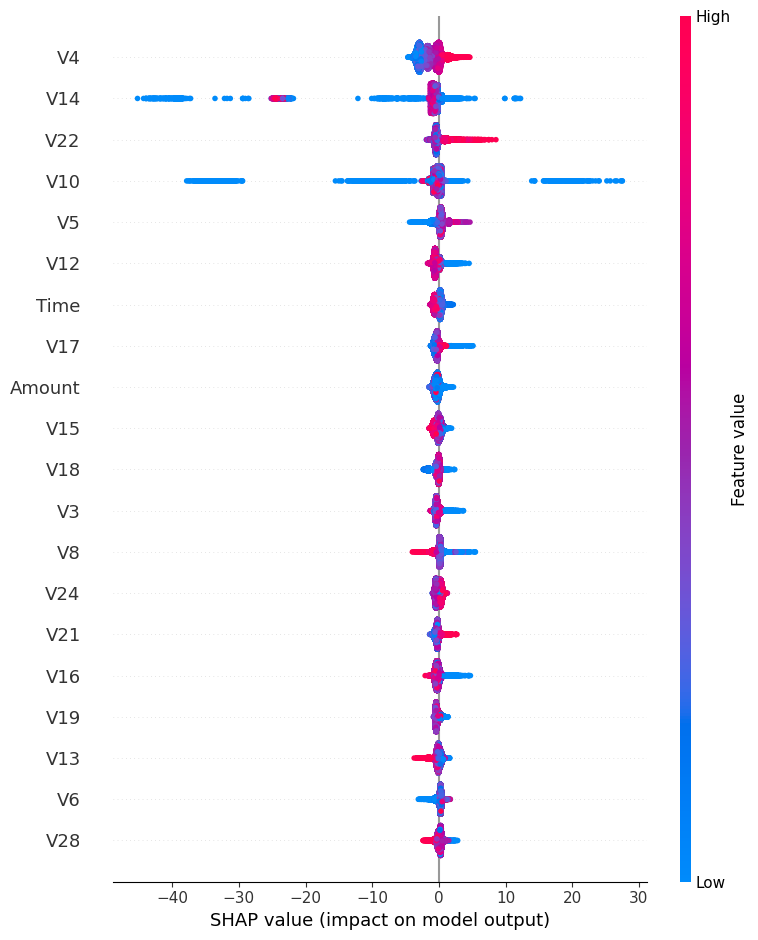

In [2]:
# =============================
# 1. Upload ZIP file
# =============================
from google.colab import files
import zipfile
import pandas as pd

# Upload zip
uploaded = files.upload()

# Extract zip
for filename in uploaded.keys():
    if filename.endswith(".zip"):
        with zipfile.ZipFile(filename, 'r') as zip_ref:
            zip_ref.extractall("data")
        print(f" Extracted: {filename}")

# =============================
# 2. Load dataset (CSV inside ZIP)
#    (change filename if needed)
# =============================
import os

# list extracted files
os.listdir("data")

# Example: load creditcard.csv
df = pd.read_csv("data/creditcard.csv")
print(df.head())
print(df.shape)

# =============================
# 3. Train-test split
# =============================
from sklearn.model_selection import train_test_split

X = df.drop("Class", axis=1)   # features
y = df["Class"]                # target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# =============================
# 4. ML Model (XGBoost)
# =============================
!pip install xgboost shap

from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

model = XGBClassifier(use_label_encoder=False, eval_metric="logloss")
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]

print("Classification Report:\n", classification_report(y_test, y_pred))
print("AUC Score:", roc_auc_score(y_test, y_proba))

# =============================
# 5. Explainability (SHAP)
# =============================
import shap
shap.initjs()

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Summary plot (top features)
shap.summary_plot(shap_values, X_test)
